In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input, Masking
from tensorflow.keras.optimizers import Adam
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow.keras.backend as K
from imblearn.over_sampling import RandomOverSampler
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pwd

Mounted at /content/drive
/content


In [ ]:

data = pd.read_csv("/content/drive/MyDrive/CS 224N Project/prelabel_output.csv", engine="python")
data = data.drop(columns=['Unnamed: 0'])
data = data[data['party'] != 'I']
print(np.shape(data))
data

(15393, 16)


,speech_id,category,country,phrase,speech,date,word_count,speakerid,lastname,firstname,chamber,state,gender,party,district,nonvoting
0,1110000096,adversary,Iran,and nation to pay our bills.,Mr. Speaker. at the beginning of the 110th Con...,2009-01-06,346,111116270,CARDOZA,DENNIS,H,CA,M,D,18.0,voting
1,1110000134,ally,Israel,it looks like the days of the old west have re...,Madam Speaker. it looks like the days of the O...,2009-01-06,219,111120850,POE,TED,H,TX,M,R,2.0,voting
2,1110000134,ally,Israel,innocent nation civilians have been targeted b...,Madam Speaker. it looks like the days of the O...,2009-01-06,219,111120850,POE,TED,H,TX,M,R,2.0,voting
3,1110000134,ally,Israel,these terrorist outlaws have fired over 8.000 ...,Madam Speaker. it looks like the days of the O...,2009-01-06,219,111120850,POE,TED,H,TX,M,R,2.0,voting
4,1110000134,ally,Israel,these extremists call for the total destructio...,Madam Speaker. it looks like the days of the O...,2009-01-06,219,111120850,POE,TED,H,TX,M,R,2.0,voting
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15570,1110178940,adversary,Russia,and ensuring that our nuclear inspectors are o...,Mr. President. as we end this year. I wanted t...,2010-12-22,2487,111118701,BOXER,BARBARA,S,CA,F,D,NaN,voting
15571,1110178940,adversary,Iran,we enacted tough new sanctions against iranano...,Mr. President. as we end this year. I wanted t...,2010-12-22,2487,111118701,BOXER,BARBARA,S,CA,F,D,NaN,voting
15572,1110178944,adversary,Russia,following the 2008 war with nation.,Mr. President. I rise today to mention a disti...,2010-12-22,346,111117261,KERRY,JOHN,S,MA,M,D,NaN,voting
15573,1110179008,adversary,Russia,more than a year has passed since american ins...,Madam President. when we convened this Congres...,2010-12-22,1555,111120961,REID,HARRY,S,NV,M,D,NaN,voting


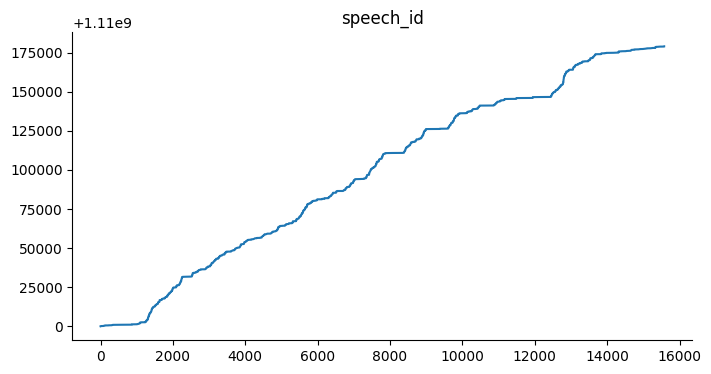

In [ ]:
# @title speech_id

from matplotlib import pyplot as plt
data['speech_id'].plot(kind='line', figsize=(8, 4), title='speech_id')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
texts = data['phrase'].values
categories = data['category'].apply(lambda x: 1 if x == 'ally' else 0 if x == 'adversary' else None)
parties = data['party'].apply(lambda x: 1 if x == 'D' else 0 if x == 'R' else None)
data['category'] = categories
data['party'] = parties


In [ ]:
clean_data = data.drop(columns=['district'])
all_data_df = clean_data[['phrase', 'category', 'party']]

In [ ]:
data['category'] = categories
data['party'] = parties

In [ ]:
print(data['party'])
print(data['category'])
print(all_data_df)

0        1
1        0
2        0
3        0
4        0
        ..
15570    1
15571    1
15572    1
15573    1
15574    1
Name: party, Length: 15393, dtype: int64
0        0
1        1
2        1
3        1
4        1
        ..
15570    0
15571    0
15572    0
15573    0
15574    0
Name: category, Length: 15393, dtype: int64
                                                  phrase  category  party
0                           and nation to pay our bills.         0      1
1      it looks like the days of the old west have re...         1      0
2      innocent nation civilians have been targeted b...         1      0
3      these terrorist outlaws have fired over 8.000 ...         1      0
4      these extremists call for the total destructio...         1      0
...                                                  ...       ...    ...
15570  and ensuring that our nuclear inspectors are o...         0      1
15571  we enacted tough new sanctions against iranano...         0      1
15572  

In [ ]:
category_min = min(all_data_df[all_data_df['category'] == 1].shape[0], all_data_df[all_data_df['category'] == 0].shape[0])
party_min = min(all_data_df[all_data_df['party'] == 1].shape[0], all_data_df[all_data_df['party'] == 0].shape[0])

category_pos = all_data_df[(all_data_df['category']==1)]
category_neg = all_data_df[(all_data_df['category']==0)]

party_pos = all_data_df[(all_data_df['party']==1)]
party_neg = all_data_df[(all_data_df['party']==0)]

category_pos_chosen = category_pos.sample(n=category_min,random_state=1)
category_neg_chosen = category_neg.sample(n=category_min,random_state=1)


party_pos_chosen = party_pos.sample(n=party_min,random_state=1)
party_neg_chosen = party_neg.sample(n=party_min,random_state=1)

# problem 1: category pos/neg has different training size than party pos/neg

In [ ]:
import re

def tokenize_text(text):
    # Tokenizes the sentence considering whitespace and punctuation
    tokens = re.findall(r"\b\w+\b|[^\w\s]", text)  # Split by word boundaries or non-word characters
    tokens = [token.lower() for token in tokens]  # Convert to lowercase  # Add <start> and <end> tokens
    tokens = ["<start>"] + tokens + ["<end>"]
    return tokens

tokenized_texts = [tokenize_text(text) for text in texts]
print(tokenized_texts)


flat_texts = [' '.join(tokens) for tokens in tokenized_texts]

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(flat_texts)


In [ ]:
def split_data(data, label_col, train_frac=0.7, validate_frac=0.1):
    n_train = int(len(data) * train_frac)
    n_validate = int(len(data) * validate_frac)

    train_data = data.iloc[:n_train]
    validate_data = data.iloc[n_train:n_train + n_validate]
    test_data = data.iloc[n_train + n_validate:]

    return train_data, validate_data, test_data

# Split the data
category_pos_train, category_pos_validate, category_pos_test = split_data(category_pos_chosen, 'category', train_frac=0.7, validate_frac=0.1)
category_neg_train, category_neg_validate, category_neg_test = split_data(category_neg_chosen, 'category', train_frac=0.7, validate_frac=0.1)
party_pos_train, party_pos_validate, party_pos_test = split_data(party_pos_chosen, 'party', train_frac=0.7, validate_frac=0.1)
party_neg_train, party_neg_validate, party_neg_test = split_data(party_neg_chosen, 'party', train_frac=0.7, validate_frac=0.1)

# Combine the training, validation, and testing sets
train_data_category = pd.concat([category_pos_train, category_neg_train])
validate_data_category = pd.concat([category_pos_validate, category_neg_validate])
test_data_category = pd.concat([category_pos_test, category_neg_test])

train_data_party = pd.concat([party_pos_train, party_neg_train])
validate_data_party = pd.concat([party_pos_validate, party_neg_validate])
test_data_party = pd.concat([party_pos_test, party_neg_test])

#problem 2: dimension of train_data_category different than train_data_party

In [ ]:
# Tokenize texts for category data
tokenized_texts_category_train = [tokenize_text(text) for text in train_data_category['phrase']]
tokenized_texts_category_validate = [tokenize_text(text) for text in validate_data_category['phrase']]
tokenized_texts_category_test = [tokenize_text(text) for text in test_data_category['phrase']]

# Convert texts to sequences of integers
flat_texts_category_train = [' '.join(tokens) for tokens in tokenized_texts_category_train]
flat_texts_category_validate = [' '.join(tokens) for tokens in tokenized_texts_category_validate]
flat_texts_category_test = [' '.join(tokens) for tokens in tokenized_texts_category_test]

tokenizer_category = Tokenizer(num_words=10000)
tokenizer_category.fit_on_texts(flat_texts_category_train)
sequences_category_train = tokenizer_category.texts_to_sequences(flat_texts_category_train)
sequences_category_validate = tokenizer_category.texts_to_sequences(flat_texts_category_validate)
sequences_category_test = tokenizer_category.texts_to_sequences(flat_texts_category_test)
max_length_category = max(len(seq) for seq in sequences_category_train + sequences_category_validate + sequences_category_test)
X_train_category = pad_sequences(sequences_category_train, maxlen=max_length_category, padding='post')
X_validate_category = pad_sequences(sequences_category_validate, maxlen=max_length_category, padding='post')
X_test_category = pad_sequences(sequences_category_test, maxlen=max_length_category, padding='post')

# Tokenize texts for party data
tokenized_texts_party_train = [tokenize_text(text) for text in train_data_party['phrase']]
tokenized_texts_party_validate = [tokenize_text(text) for text in validate_data_party['phrase']]
tokenized_texts_party_test = [tokenize_text(text) for text in test_data_party['phrase']]

flat_texts_party_train = [' '.join(tokens) for tokens in tokenized_texts_party_train]
flat_texts_party_validate = [' '.join(tokens) for tokens in tokenized_texts_party_validate]
flat_texts_party_test = [' '.join(tokens) for tokens in tokenized_texts_party_test]

tokenizer_party = Tokenizer(num_words=10000)
tokenizer_party.fit_on_texts(flat_texts_party_train)
sequences_party_train = tokenizer_party.texts_to_sequences(flat_texts_party_train)
sequences_party_validate = tokenizer_party.texts_to_sequences(flat_texts_party_validate)
sequences_party_test = tokenizer_party.texts_to_sequences(flat_texts_party_test)
max_length_party = max(len(seq) for seq in sequences_party_train + sequences_party_validate + sequences_party_test)
X_train_party = pad_sequences(sequences_party_train, maxlen=max_length_party, padding='post')
X_validate_party = pad_sequences(sequences_party_validate, maxlen=max_length_party, padding='post')
X_test_party = pad_sequences(sequences_party_test, maxlen=max_length_party, padding='post')

# Convert labels to numpy array
y_train_category = train_data_category['category'].values
y_validate_category = validate_data_category['category'].values
y_test_category = test_data_category['category'].values
y_train_party = train_data_party['party'].values
y_validate_party = validate_data_party['party'].values
y_test_party = test_data_party['party'].values

In [ ]:
## pretraining generla context
word2vec_model = api.load("word2vec-google-news-300")
embedding_dim = word2vec_model.vector_size

num_words = 10000  # Set num_words based on your needs
embedding_matrix = np.zeros((num_words, embedding_dim))

# Populate embedding matrix with Word2Vec embeddings
for word, i in tokenizer_category.word_index.items():
    if i < num_words:
        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:

# contrastive loss function
def contrastive_loss(y_true, y_pred, margin=1):
    y_true = K.cast(y_true, dtype=K.floatx())
    square_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * square_pred + (1 - y_true) * margin_square)


In [ ]:
import matplotlib.pyplot as plt

# plot training and validation loss
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Model building function
def build_model(input_shape, embedding_matrix, num_words, embedding_dim, l2_reg):
    text_input = Input(shape=(input_shape,))
    masking = Masking(mask_value=0.0)(text_input)
    embedding = Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False)(masking)
    bi_lstm1 = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(l2_reg)))(embedding)
    bi_lstm2 = Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(l2_reg)))(bi_lstm1)
    dropout = Dropout(0.3)(bi_lstm2)
    output = Dense(1, activation='sigmoid', kernel_regularizer=l2(l2_reg))(dropout)
    model = Model(inputs=text_input, outputs=output)
    return model

In [ ]:
# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Build and compile model for category prediction
model_category = build_model(max_length_category, embedding_matrix, num_words, embedding_dim,0.001)
model_category.compile(optimizer=Adam(), loss=BinaryCrossentropy(), metrics=['accuracy'])
# try use less data to make model overfit, then increase dataset and tweak hyper parameters


# Train with EarlyStopping for category prediction
history_category = model_category.fit(
    X_train_category,
    y_train_category,
    epochs=20,
    batch_size=32,
    validation_data=(X_validate_category, y_validate_category),
    callbacks=[early_stopping]
)

# Evaluate category model
category_eval = model_category.evaluate(X_test_category, y_test_category)
print(f'Category evaluation: {category_eval}')

plot_loss(history_category, 'Category Model Loss')

# Build and compile model for party prediction
model_party = build_model(max_length_party, embedding_matrix, num_words, embedding_dim,0.0005)
model_party.compile(optimizer=Adam(), loss=BinaryCrossentropy(), metrics=['accuracy'])

# Train with EarlyStopping for party prediction
history_party = model_party.fit(
    X_train_party,
    y_train_party,
    epochs=20,
    batch_size=32,
    validation_data=(X_validate_party, y_validate_party),
    callbacks=[early_stopping]
)

# Evaluate party model
party_eval = model_party.evaluate(X_test_party, y_test_party)
print(f'Party evaluation: {party_eval}')

plot_loss(history_party, 'Party Model Loss')


NameError: name 'build_model' is not defined

In [ ]:
# f1 scores, etc

category_pred = model_category.predict(X_test_category).flatten()
category_pred = (category_pred > 0.5).astype(int)

category_accuracy = accuracy_score(y_test_category, category_pred)
category_precision = precision_score(y_test_category, category_pred)
category_recall = recall_score(y_test_category, category_pred)
category_f1 = f1_score(y_test_category, category_pred)

category_model_save_path = '/content/drive/MyDrive/CS 224N Project/sentiment_bilstm_category_model.h5'
model_category.save(category_model_save_path)

print(f'Category Accuracy Score: {category_accuracy:.4f}')
print(f'Category Precision Score: {category_precision:.4f}')
print(f'Category Recall Score: {category_recall:.4f}')
print(f'Category F1 Score: {category_f1:.4f}')

party_pred = model_party.predict(X_test_party).flatten()
party_pred = (party_pred > 0.5).astype(int)


party_accuracy = accuracy_score(y_test_party, party_pred)
party_precision = precision_score(y_test_party, party_pred)
party_recall = recall_score(y_test_party, party_pred)
party_f1 = f1_score(y_test_party, party_pred)

print(f'Party Accuracy Score: {party_accuracy:.4f}')
print(f'Party Precision Score: {party_precision:.4f}')
print(f'Party Recall Score: {party_recall:.4f}')
print(f'Party F1 Score: {party_f1:.4f}')


85/85 [==============================] - 2s 9ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Category Accuracy Score: 0.5322
Category Precision Score: 0.5186
Category Recall Score: 0.8979
Category F1 Score: 0.6575
94/94 [==============================] - 4s 15ms/step
Party Accuracy Score: 0.5706
Party Precision Score: 0.5708
Party Recall Score: 0.5692
Party F1 Score: 0.5700


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
